In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Problem *5.38

### (a)

The magnitude has to be 0 at 0 and $\pi$. This means that placing zeros with maximal effect on those values of $\omega$, which equates to placing them on the unit circle. The two zeros are then
$$
z_{1} = 1 \cdot e^{j 0} = 1 \qquad z_{2} = 1 \cdot e^{j \pi} = -1
$$

Knowing that the maximal magnitude should be placed at $\pm \frac{\pi}{4}$ it is known that poles at

$$
p_{1} = r_{2} \cdot e^{j \frac{\pi}{4}} \qquad p_{2} = r_{4} \cdot e^{-j \frac{\pi}{4}}
$$

Since we want a magnitude response of $\frac{1}{\sqrt{2}}$ at a specific frequency away from the pole, equation (5.120) can be used to approximate a value of the pole radius $r$.

\begin{align*}
\Delta\omega &\approx 2(1 - r)\\
0.1 &\approx 2(1 - r)\\
0.05 &\approx 1 - r\\
r &\approx 0.95
\end{align*}

The IIR filter can then be described with the following equation
$$
H(e^{ j\omega }) = b_{0} \frac{(1 - e^{ -j\omega })(1 + e^{ -j\omega })}{\left( 1 - 0.95e^{ j \frac{\pi}{4} } e^{ -j\omega } \right) \left( 1 - 0.95e^{ -j \frac{\pi}{4}} e^{ -j\omega }\right) }
$$

Knowing that the maximal value will be 1 and that it reaches this value at $\omega = \frac{\pi}{4}$, the value of the scaling factor can be found as:

\begin{align*}
1 &= \left| b_{0} \frac{\left( 1 - e^{ -j \frac{\pi}{4} } \right)\left( 1 + e^{ -j \frac{\pi}{4} } \right)}{\left( 1 - 0.95e^{ j \frac{\pi}{4} } e^{ -j \frac{\pi}{4} } \right) \left( 1 - 0.95e^{ -j \frac{\pi}{4}} e^{ -j \frac{\pi}{4} }\right) } \right|\\
&= \left| b_{0} \frac{1 - e^{ -2j \frac{\pi}{4} }}{(1 - 0.95 e^{ 0 }) \left( 1 - 0.95 e^{ -2j \frac{\pi}{4} } \right) } \right|\\
&= \left| b_{0} \frac{1 - (-j)}{0.05 (1 - 0.95 (-j))} \right|\\
&= |b_{0}| \frac{|1 + j|}{|0.05 + 0.0475j|}\\
&= |b_{0}| \frac{\sqrt{ 1^{2} + 1^{2} }}{\sqrt{ 0.05^{2} + 0.0475^{2} }}\\
|b_{0}| &= \frac{\sqrt{ 0.05^{2} + 0.0475^{2} }}{\sqrt{ 2 }}\\
|b_{0}| &\approx 0.0488
\end{align*}

The final system equation when transformed into the z-domain by setting $z = e^{j \omega}$ will be:

\begin{align*}
H(z) &= 0.0488 \frac{(1 - z^{ -1 })(1 + z^{ -1 })}{\left( 1 - 0.95e^{ j \frac{\pi}{4} } z^{ -1 } \right) \left( 1 - 0.95e^{ -j \frac{\pi}{4}} z^{ -1 }\right) }\\
&= \frac{0.0488 - 0.0488 z^{ 2 }}{1 - 1.3435 z + 0.9025 z^{ 2 }}
\end{align*}

### (b)

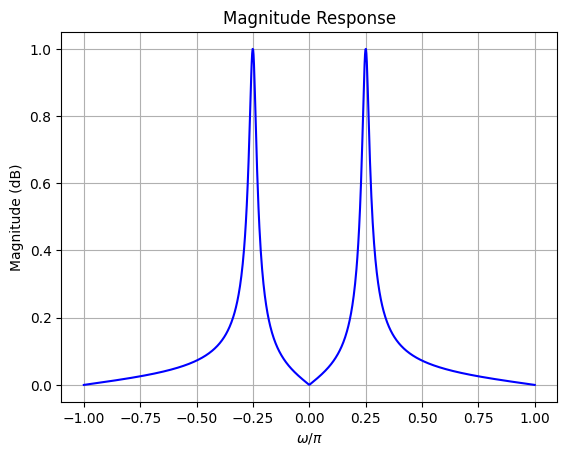

In [25]:
num = [0.0488, 0, -0.0488]
den = [1, -1.3435, 0.9025]

w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)

plt.figure()
plt.plot(w/np.pi, abs(H), 'b')
plt.title('Magnitude Response')
plt.xlabel('$\omega/\pi$')
plt.ylabel('Magnitude (dB)')
plt.grid()

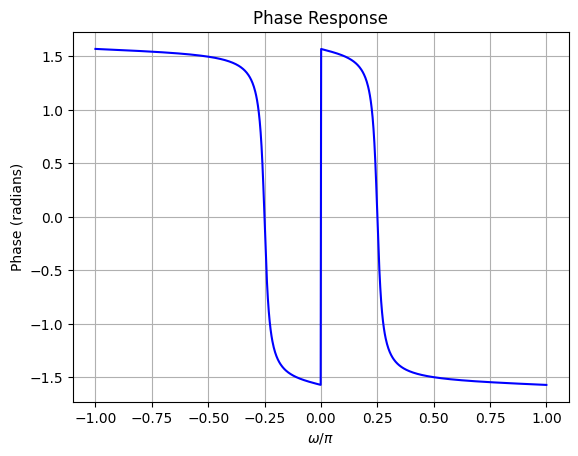

In [26]:
plt.figure()
plt.plot(w/np.pi, np.angle(H), 'b')
plt.title('Phase Response')
plt.xlabel('$\omega/\pi$')
plt.ylabel('Phase (radians)')
plt.grid()

### (c)

C:\Users\henri\AppData\Local\Temp\ipykernel_7848\4220953043.py:1: UserWarning: The filter's denominator is extremely small at frequencies [-3.142, 3.142],             around which a singularity may be present
  _, gd = signal.group_delay((den,num), w=w)


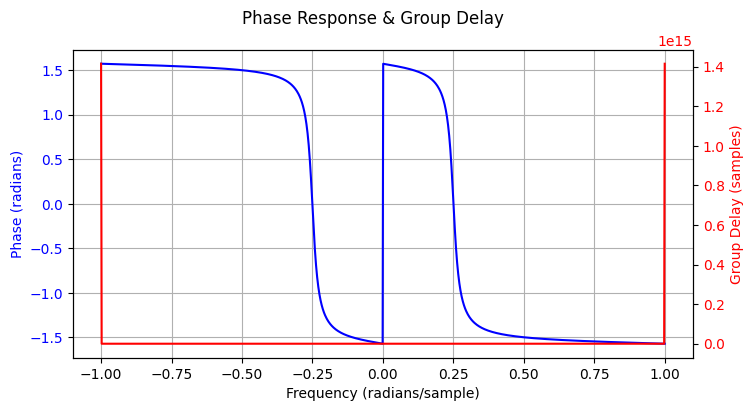

In [27]:
_, gd = signal.group_delay((den,num), w=w)

# Create a figure
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot phase response on primary y-axis
ax1.plot(w/np.pi, np.angle(H), 'b', label="Phase Response")
ax1.set_xlabel("Frequency (radians/sample)")
ax1.set_ylabel("Phase (radians)", color="b")
ax1.tick_params(axis='y', labelcolor="b")
ax1.grid()

# Create secondary y-axis for group delay
ax2 = ax1.twinx()
ax2.plot(w/np.pi, gd, 'r', label="Group Delay")
ax2.set_ylabel("Group Delay (samples)", color="r")
ax2.tick_params(axis='y', labelcolor="r")

# Show the plot
fig.suptitle("Phase Response & Group Delay")
plt.show()

## Problem *5.39

### (a)